# Fase 1: Análisis exploratorio

In [1]:
# Importación de librerías necesarias para el análisis de datos y visualización.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Función para cargar datos desde un archivo CSV.

def cargar_datos(ruta):        # Define la función que carga el CSV.
    df = pd.read_csv(ruta)     # Lee el archivo CSV y lo convierte en DataFrame.
    return df                  # Devuelve el DataFrame para poder usarlo fuera de la función.

df = cargar_datos("files/hr.csv")    # Llama a la función pasándole el nombre del archivo.

In [3]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80.0,1,6,3.0,3,2,2,2,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,34.0,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,NaN,0,6,3.0,4,4,3,1,2.0
1470,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,...,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,...,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,...,3,80.0,1,1,2.0,3,1,0,0,0.0


In [4]:
# Función para mostrar la estructura del DataFrame.

def resumen_estructural(df):                                      # Define la función que muestra la estructura del DataFrame.
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")       # Muestra cuántas filas y columnas tiene.
    print("\nTipos de dato:")                                          
    print(df.dtypes)                                              # Muestra el tipo de dato de cada columna.
    print("\nNulos por columna:")                                      
    print(df.isnull().sum()[df.isnull().sum() > 0])               # Muestra las columnas que tienen algún nulo.
    print(f"\nDuplicados: {df.duplicated().sum()}")               # Muestra cuántas filas están duplicadas.

resumen_estructural(df) 

Filas: 1474, Columnas: 35

Tipos de dato:
Age                         float64
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction             float64
MaritalStatus                   str
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours         

A primera vista vemos que tendremos que revisar los tipos de datos de cada columna, ya que por ejemplo, age no tiene sentido que sea un float y no un entero. Por otra parte vemos que existen nulos que vamos a tener que revisar y tratar.

In [5]:
df.nunique().sort_values()    # Muestro cuántos valores distintos tiene cada columna, ordenados de menor a mayor

Over18                         1
EmployeeCount                  1
StandardHours                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
BusinessTravel                 3
Department                     3
RelationshipSatisfaction       4
JobSatisfaction                4
JobInvolvement                 4
MaritalStatus                  4
StockOptionLevel               4
WorkLifeBalance                4
EnvironmentSatisfaction        4
JobLevel                       5
Education                      5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

Tendremos también que revisar si tiene sentido mantener las columnas EmployeeCount y Over18 ya que todos los registros tienen el mismo resultado, por lo que no parece que aporte ningún dato relevante.

In [6]:
# Función para mostrar las filas duplicadas.

def ver_duplicados(df):                       # Define la función que muestra las filas duplicadas.
    print(df[df.duplicated(keep=False)])      # Muestra ambas copias de cada fila duplicada, no solo la repetida.

ver_duplicados(df)                            # Llama a la función para inspeccionar los duplicados antes de borrar nada.

       Age Attrition BusinessTravel  DailyRate              Department  \
67    45.0        No  Travel_Rarely       1339  Research & Development   
184   53.0        No  Travel_Rarely       1084  Research & Development   
1041  28.0        No  Travel_Rarely        866                   Sales   
1222  24.0       Yes  Travel_Rarely        240         Human Resources   
1470  28.0        No  Travel_Rarely        866                   Sales   
1471  53.0        No  Travel_Rarely       1084  Research & Development   
1472  24.0       Yes  Travel_Rarely        240         Human Resources   
1473  45.0        No  Travel_Rarely       1339  Research & Development   

      DistanceFromHome  Education   EducationField  EmployeeCount  \
67                   7          3    Life Sciences              1   
184                 13          2          Medical              1   
1041                 5          3          Medical              1   
1222                22          1  Human Resources       

Así vemos que los duplicados tienen exactamente los mismos datos en todas las columnas, así que podemos eliminar uno de ellos sin problema.

In [7]:
# Función para eliminar filas duplicadas.

def eliminar_duplicados(df):                                                # Define la función que elimina las filas duplicadas.
    filas_antes = df.shape[0]                                               # Guarda cuántas filas había antes de eliminar para la comprobación.
    df = df.drop_duplicates()                                               # Elimina las filas que son exactamente iguales en todas las columnas.
    filas_despues = df.shape[0]                                             # Guarda cuántas filas quedan después de eliminar para la comprobación.
    print(f"Se eliminaron {filas_antes - filas_despues} filas duplicadas")  # Muestra cuántas se quitaron (comprobación).
    return df                                                               # Devuelve el DataFrame sin duplicados.

df = eliminar_duplicados(df)                                                # Sobrescribe df con la versión limpia.

Se eliminaron 4 filas duplicadas


In [8]:
resumen_estructural(df) 

Filas: 1470, Columnas: 35

Tipos de dato:
Age                         float64
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction             float64
MaritalStatus                   str
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours         

Vemos que el DataFrame tiene 4 filas menos que antes y que ya no existen duplicados.

In [9]:
# Vamos a ver el porcentaje de nulos que hay en cada columna.

def porcentaje_nulos(df):                                               # Define la función que muestra el porcentaje de nulos por columna.
    nulos = df.isnull().sum()                                           # Cuenta cuántos nulos tiene cada columna.
    porcentaje = (nulos / len(df)) * 100                                # Calcula qué porcentaje del total representa cada cantidad de nulos.
    resumen = pd.DataFrame({"nulos": nulos, "porcentaje": porcentaje})  # Junta ambas cosas en una tabla para verlo más claro.
    resumen = resumen[resumen["nulos"] > 0]                             # Se queda solo con las columnas que tienen al menos un nulo.
    resumen = resumen.sort_values("porcentaje", ascending=False)        # Ordena de mayor a menor porcentaje de nulos.
    print(resumen)                                                      # Muestra la tabla.

porcentaje_nulos(df)

                       nulos  porcentaje
StandardHours            161   10.952381
YearsWithCurrManager     147   10.000000
MaritalStatus            132    8.979592
BusinessTravel           117    7.959184
TrainingTimesLastYear     88    5.986395
Age                       73    4.965986
EducationField            58    3.945578
OverTime                  44    2.993197
Department                29    1.972789
JobSatisfaction           29    1.972789
MonthlyIncome             14    0.952381


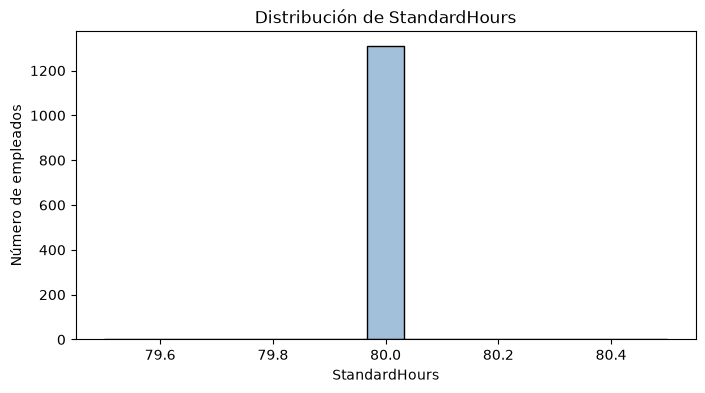

In [10]:
# Vamos a ver cómo se distribuyen los datos en StandardHours.

def ver_distribucion_num(df, columna):                                      # Define la función que visualiza la distribución de una columna numérica.
    plt.figure(figsize=(8, 4))                                              # Define el tamaño del gráfico.
    sns.histplot(data=df, x=columna, bins=15, kde=True, color="steelblue")  # Muestra el histograma con curva de densidad.
    plt.title(f"Distribución de {columna}")                                 # Título del gráfico.
    plt.xlabel(columna)                                                     # Etiqueta del eje x.
    plt.ylabel("Número de empleados")                                       # Etiqueta del eje y.
    plt.show()                                                              # Muestra el gráfico.

ver_distribucion_num(df, "StandardHours")

La columna StandardHours la podemos eliminar ya que todos los valores son 80 y el resto son nulos, así que no diferencia en nada a los empleados.

In [11]:
df = df.drop(columns=["StandardHours"])
porcentaje_nulos(df)

                       nulos  porcentaje
YearsWithCurrManager     147   10.000000
MaritalStatus            132    8.979592
BusinessTravel           117    7.959184
TrainingTimesLastYear     88    5.986395
Age                       73    4.965986
EducationField            58    3.945578
OverTime                  44    2.993197
Department                29    1.972789
JobSatisfaction           29    1.972789
MonthlyIncome             14    0.952381


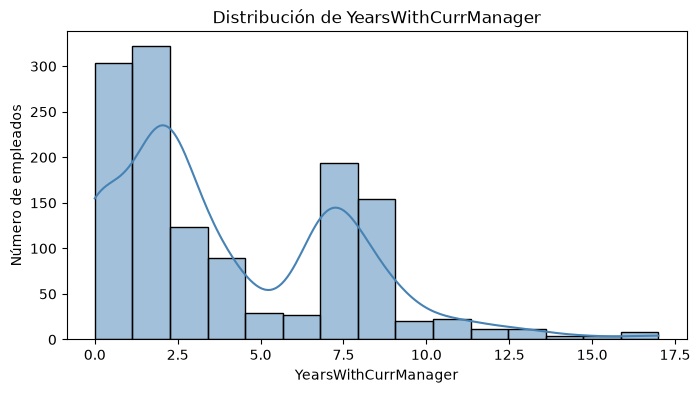

In [12]:
# Vamos a ver qué pasa con YearsWithCurrManager (numérica).

ver_distribucion_num(df, "YearsWithCurrManager")

In [13]:
# Vamos a comprobar si los nulos en YearsWithCurrManager siguen algún patrón antes de tomar una decisión sobre cómo tratarlos.

df[df["YearsWithCurrManager"].isnull()]["YearsAtCompany"].describe()    # Muestra las estadísticas de YearsAtCompany solo para las filas donde YearsWithCurrManager es nulo.

count    147.000000
mean       7.360544
std        6.367668
min        0.000000
25%        3.000000
50%        6.000000
75%        9.000000
max       33.000000
Name: YearsAtCompany, dtype: float64

Con el describe comprobamos si YearsWithCurrManager sigue algún patrón relacionado con YearsAtCompany (por ejemplo, empleados recién llegados sin manager asignado todavía) pero el máximo de antigüedad entre esas filas es de 33 años, así que la hipótesis no se sostiene y los nulos parecen aleatorios.

Al ver la distribución gráfica, vemos que es asimétrica y que tiene 2 picos (uno en 0-2 años y otro en 7-9 años), con una cola larga hacia la derecha. En este caso la media queda distorsionada por los outliers, así que, teniendo en cuenta que los nulos son el 10% de los datos (es decir, son pocos) la mejor opción es imputar con la mediana.

In [14]:
df["YearsWithCurrManager"] = df["YearsWithCurrManager"].fillna(df["YearsWithCurrManager"].median())  # Imputamos los nulos con la mediana
porcentaje_nulos(df)

                       nulos  porcentaje
MaritalStatus            132    8.979592
BusinessTravel           117    7.959184
TrainingTimesLastYear     88    5.986395
Age                       73    4.965986
EducationField            58    3.945578
OverTime                  44    2.993197
Department                29    1.972789
JobSatisfaction           29    1.972789
MonthlyIncome             14    0.952381


In [15]:
# Ahora toca MaritalStatus (categórica).

def ver_distribucion_cat(df, columna):                                             # Define la función que muestra la distribución de una columna categórica.
    conteo = df[columna].value_counts()                                            # Cuenta cuántas veces aparece cada categoría.
    porcentaje = df[columna].value_counts(normalize=True) * 100                    # Calcula qué porcentaje representa cada categoría.
    resumen = pd.DataFrame({"conteo": conteo, "porcentaje": porcentaje.round(2)})  # Junta ambas cosas en una tabla.
    print(resumen)                                                                 # Muestra la tabla.

ver_distribucion_cat(df, "MaritalStatus")

               conteo  porcentaje
MaritalStatus                    
Married           603       45.07
Single            436       32.59
Divorced          296       22.12
Marreid             3        0.22


Vemos que existe una 4ª categoría "marreid" que claramente se trata de un error de escritura, vamos a corregirla para que esos casos se unan con los correctos "married".

In [16]:
df["MaritalStatus"] = df["MaritalStatus"].replace("Marreid", "Married")
ver_distribucion_cat(df, "MaritalStatus")

               conteo  porcentaje
MaritalStatus                    
Married           606       45.29
Single            436       32.59
Divorced          296       22.12


In [17]:
# Vamos a comprobar si los nulos en MaritalStatus siguen algún patrón antes de tomar una decisión sobre cómo tratarlos.

def comparar_grupo_con_nulos(df, columna_con_nulos, columna_grupo):                              # Define la función que compara la distribución de un grupo entre filas con y sin nulos.
    print("Distribución en filas con nulo:")
    print(df[df[columna_con_nulos].isnull()][columna_grupo].value_counts(normalize=True) * 100)  # Muestra el porcentaje de cada categoría del grupo, solo donde hay nulo.
    print("\nDistribución general:")
    print(df[columna_grupo].value_counts(normalize=True) * 100)                                  # Muestra el porcentaje de cada categoría del grupo, en todo el dataset.

comparar_grupo_con_nulos(df, "MaritalStatus", "Gender")                                          # Compara si los nulos de MaritalStatus se concentran en algún género.

Distribución en filas con nulo:
Gender
Male      62.121212
Female    37.878788
Name: proportion, dtype: float64

Distribución general:
Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64


Podemos ver que no existe patrón en los nulos de MaritalStatus. 

Aunque no exista una categoría con más de un 50% de los datos, sí que Married está muy cerca de ese 50% y, como el porcentaje de nulos es bajo (8,9%), no tiene sentido crear  una categoría nueva así que los vamos a imputar con la moda.

In [18]:
df["MaritalStatus"] = df["MaritalStatus"].fillna(df["MaritalStatus"].mode()[0])
porcentaje_nulos(df)

                       nulos  porcentaje
BusinessTravel           117    7.959184
TrainingTimesLastYear     88    5.986395
Age                       73    4.965986
EducationField            58    3.945578
OverTime                  44    2.993197
Department                29    1.972789
JobSatisfaction           29    1.972789
MonthlyIncome             14    0.952381


In [19]:
# Ahora vamos con BusinessTravel (categórica).

ver_distribucion_cat(df, "BusinessTravel")       # Primero vemos la distribución.

                   conteo  porcentaje
BusinessTravel                       
Travel_Rarely         951       70.29
Travel_Frequently     263       19.44
Non-Travel            139       10.27


In [20]:
comparar_grupo_con_nulos(df, "BusinessTravel", "Department")    # Compara si los nulos de BusinessTravel se concentran en algún departamento.

Distribución en filas con nulo:
Department
Research & Development    62.068966
Sales                     32.758621
Human Resources            5.172414
Name: proportion, dtype: float64

Distribución general:
Department
Research & Development    65.163081
Sales                     30.464955
Human Resources            4.371964
Name: proportion, dtype: float64


Travel_Rarely concentra el 70.29% de los casos, muy por encima del resto (Travel_Frequently 19.44%, Non-Travel 10.27%), así que hay una categoría claramente dominante. Hemos confirmado también que los nulos no siguen ningún patrón (tendría sentido que la frecuencia de viaje dependiera del puesto que ocupan, pero no es así), así que vamos a imputar con la moda.

In [21]:
df["BusinessTravel"] = df["BusinessTravel"].fillna(df["BusinessTravel"].mode()[0])
porcentaje_nulos(df)

                       nulos  porcentaje
TrainingTimesLastYear     88    5.986395
Age                       73    4.965986
EducationField            58    3.945578
OverTime                  44    2.993197
Department                29    1.972789
JobSatisfaction           29    1.972789
MonthlyIncome             14    0.952381


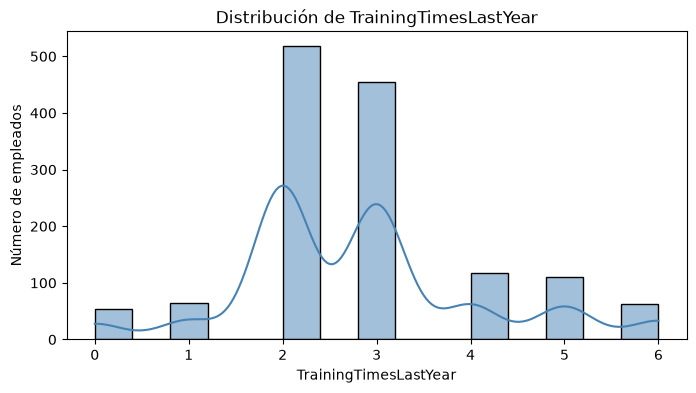

In [22]:
# Vamos con TrainingTimesLastYear (numérica).

ver_distribucion_num(df, "TrainingTimesLastYear")

In [23]:
comparar_grupo_con_nulos(df, "TrainingTimesLastYear", "Department")     # Compara si los nulos de TrainingTimesLastYear se concentran en algún departamento.

Distribución en filas con nulo:
Department
Research & Development    71.428571
Sales                     23.809524
Human Resources            4.761905
Name: proportion, dtype: float64

Distribución general:
Department
Research & Development    65.163081
Sales                     30.464955
Human Resources            4.371964
Name: proportion, dtype: float64


La distribución de TrainingTimesLastYear está muy concentrada en los valores 2 y 3, sin un sesgo fuerte. La mediana da un valor entero real y representativo, mientras que la media generaría un decimal sin sentido para una variable que cuenta número de formaciones, así que vamos a imputar con la mediana.

In [24]:
df["TrainingTimesLastYear"] = df["TrainingTimesLastYear"].fillna(df["TrainingTimesLastYear"].median())
porcentaje_nulos(df)

                 nulos  porcentaje
Age                 73    4.965986
EducationField      58    3.945578
OverTime            44    2.993197
Department          29    1.972789
JobSatisfaction     29    1.972789
MonthlyIncome       14    0.952381


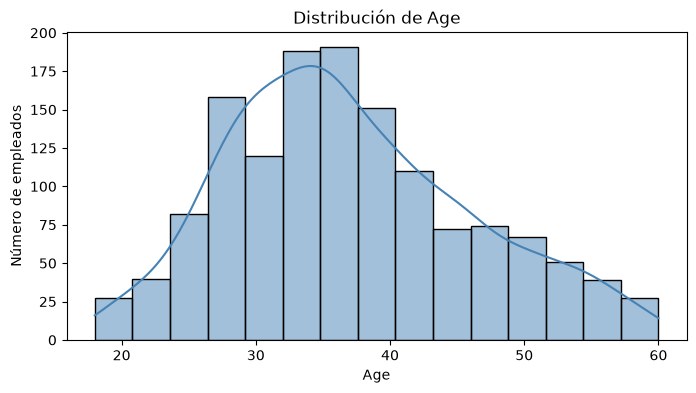

In [26]:
# Vamos con Age (numérica).

ver_distribucion_num(df, "Age")

In [27]:
comparar_grupo_con_nulos(df, "Age", "Department")    # Compara si los nulos de Age se concentran en algún departamento.
comparar_grupo_con_nulos(df, "Age", "JobLevel")      # Compara si los nulos de Age se concentran en algún nivel de puesto.

Distribución en filas con nulo:
Department
Research & Development    58.904110
Sales                     36.986301
Human Resources            4.109589
Name: proportion, dtype: float64

Distribución general:
Department
Research & Development    65.163081
Sales                     30.464955
Human Resources            4.371964
Name: proportion, dtype: float64
Distribución en filas con nulo:
JobLevel
2    41.095890
1    34.246575
3    10.958904
5     9.589041
4     4.109589
Name: proportion, dtype: float64

Distribución general:
JobLevel
1    36.938776
2    36.326531
3    14.829932
4     7.210884
5     4.693878
Name: proportion, dtype: float64


In [28]:
def comparar_media_mediana(df, columna):    # Define la función que compara la media y la mediana de una columna numérica.
    media = df[columna].mean()              # Calcula la media de la columna.
    mediana = df[columna].median()          # Calcula la mediana de la columna.
    print(f"Media: {media:.2f}")            # Muestra la media con 2 decimales.
    print(f"Mediana: {mediana:.2f}")        # Muestra la mediana con 2 decimales.

comparar_media_mediana(df, "Age")

Media: 36.94
Mediana: 36.00


La diferencia entre la media y la mediana de Age es muy pequeña (0.94), y los nulos no siguen ningún patrón por Department ni JobLevel, así que vamos a imputarlos con la mediana siguiendo el mismo criterio aplicado a las demás columnas numéricas.

In [29]:
df["Age"] = df["Age"].fillna(df["Age"].median())
porcentaje_nulos(df)

                 nulos  porcentaje
EducationField      58    3.945578
OverTime            44    2.993197
Department          29    1.972789
JobSatisfaction     29    1.972789
MonthlyIncome       14    0.952381


In [30]:
# Vamos con EducationField (categórica).

ver_distribucion_cat(df, "EducationField")

                  conteo  porcentaje
EducationField                      
Life Sciences        581       41.15
Medical              447       31.66
Marketing            152       10.76
Technical Degree     130        9.21
Other                 79        5.59
Human Resources       23        1.63


In [31]:
comparar_grupo_con_nulos(df, "EducationField", "Department")    # Compara si los nulos de EducationField se concentran en algún departamento.

Distribución en filas con nulo:
Department
Research & Development    65.517241
Sales                     25.862069
Human Resources            8.620690
Name: proportion, dtype: float64

Distribución general:
Department
Research & Development    65.163081
Sales                     30.464955
Human Resources            4.371964
Name: proportion, dtype: float64


Igual que en MaritalStatus, en EducationField el porcentaje de nulos es todavía inferior (3.9%), por lo que no tiene sentido crear una categoría nueva. Aunque no exista una categoría con más del 50% de los resultados, como no hay un patrón por Department en los nulos, vamos a imputarlos con la moda.

In [32]:
df["EducationField"] = df["EducationField"].fillna(df["EducationField"].mode()[0])
porcentaje_nulos(df)

                 nulos  porcentaje
OverTime            44    2.993197
Department          29    1.972789
JobSatisfaction     29    1.972789
MonthlyIncome       14    0.952381


In [33]:
# Vamos con OverTime (categórica).

ver_distribucion_cat(df, "OverTime")

          conteo  porcentaje
OverTime                    
No          1021        71.6
Yes          405        28.4


In [34]:
comparar_grupo_con_nulos(df, "OverTime", "Department")    # Compara si los nulos de OverTime se concentran en algún departamento.

Distribución en filas con nulo:
Department
Research & Development    77.272727
Sales                     20.454545
Human Resources            2.272727
Name: proportion, dtype: float64

Distribución general:
Department
Research & Development    65.163081
Sales                     30.464955
Human Resources            4.371964
Name: proportion, dtype: float64


En OverTime la mayoría de la gente (71.6%) no hace horas extra, así que hay una categoría que domina claramente. Al revisar los nulos, vimos que están un poco más concentrados en Research & Development de lo normal (77.3% frente al 65.2% habitual) y un poco menos en Sales. Es el desvío más grande que hemos visto hasta ahora, pero el desvío es pequeño, no da para tratarlos por departamento aparte, así que vamos a imputarlos con la moda.

In [35]:
df["OverTime"] = df["OverTime"].fillna(df["OverTime"].mode()[0])
porcentaje_nulos(df)

                 nulos  porcentaje
Department          29    1.972789
JobSatisfaction     29    1.972789
MonthlyIncome       14    0.952381


In [36]:
# Vamos con Department (categórica).

ver_distribucion_cat(df, "Department")

                        conteo  porcentaje
Department                                
Research & Development     939       65.16
Sales                      439       30.46
Human Resources             63        4.37


In [37]:
comparar_grupo_con_nulos(df, "Department", "JobRole")    # Compara si los nulos de Department se concentran en algún puesto concreto.

Distribución en filas con nulo:
JobRole
lABORATORY tECHNICIAN         27.586207
sALES eXECUTIVE               24.137931
rESEARCH sCIENTIST            13.793103
rESEARCH dIRECTOR             10.344828
hEALTHCARE rEPRESENTATIVE     10.344828
mANAGER                        6.896552
mANUFACTURING dIRECTOR         6.896552
Name: proportion, dtype: float64

Distribución general:
JobRole
sALES eXECUTIVE               22.176871
rESEARCH sCIENTIST            19.863946
lABORATORY tECHNICIAN         17.619048
mANUFACTURING dIRECTOR         9.863946
hEALTHCARE rEPRESENTATIVE      8.911565
mANAGER                        6.938776
sALES rEPRESENTATIVE           5.646259
rESEARCH dIRECTOR              5.442177
hUMAN rESOURCES                3.537415
Name: proportion, dtype: float64


Research & Development domina claramente con el 65.16% de los casos. Al comparar los nulos con JobRole salen varias categorías en 0%, pero con solo 29 nulos repartidos en 9 puestos distintos, no existe ningún patrón, así que imputamos con la moda.

Por otra parte vemos que tenemos que limpiar el formato de JobRole, lo haremos después.

In [38]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])
porcentaje_nulos(df)

                 nulos  porcentaje
JobSatisfaction     29    1.972789
MonthlyIncome       14    0.952381


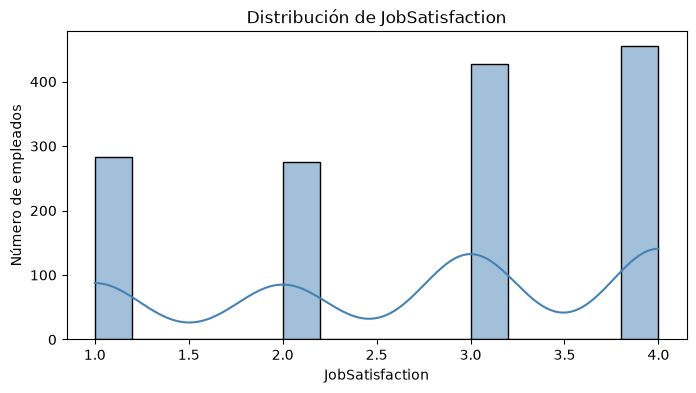

In [39]:
# Vamos con JobSatisfaction (numérica).

ver_distribucion_num(df, "JobSatisfaction")

In [40]:
# Aunque JobSatisfaction es de tipo numérico, la tratamos como categórica porque es una escala de encuesta (1-4) y no una medida continua: sus valores son categorías ordenadas, no cantidades que tenga sentido promediar.

ver_distribucion_cat(df, "JobSatisfaction")

                 conteo  porcentaje
JobSatisfaction                    
4.0                 455       31.58
3.0                 428       29.70
1.0                 283       19.64
2.0                 275       19.08


In [41]:
comparar_grupo_con_nulos(df, "JobSatisfaction", "Attrition")    # Compara si los nulos de JobSatisfaction se concentran en gente que dejó la empresa.

Distribución en filas con nulo:
Attrition
No     79.310345
Yes    20.689655
Name: proportion, dtype: float64

Distribución general:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


JobSatisfaction no tiene una categoría dominante clara (4.0 con solo 31.58%). Antes de imputar, comprobamos si los nulos se concentran en gente que dejó la empresa, ya que podría indicar que las personas más insatisfechas evitan responder la encuesta. Se observa una ligera sobrerrepresentación (20.69% frente al 16.12% general), pero es una diferencia tan pequeña que no es suficiente para confirmar la hipótesis, así que se imputa con la moda.

In [42]:
df["JobSatisfaction"] = df["JobSatisfaction"].fillna(df["JobSatisfaction"].mode()[0])
porcentaje_nulos(df)

               nulos  porcentaje
MonthlyIncome     14    0.952381


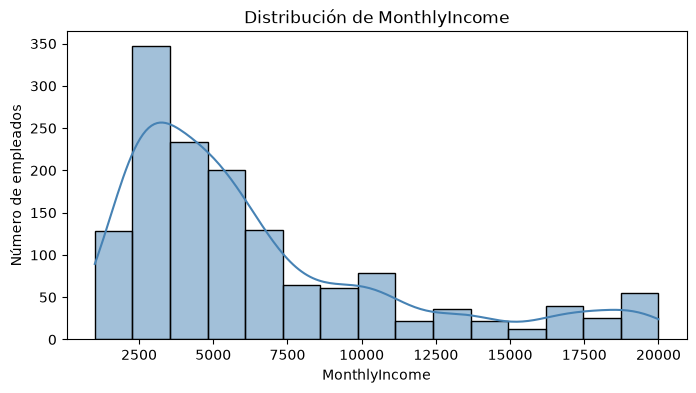

In [43]:
# Vamos con MonthlyIncome (numérica).

ver_distribucion_num(df, "MonthlyIncome")

In [44]:
comparar_grupo_con_nulos(df, "MonthlyIncome", "JobLevel")    # Compara si los nulos de MonthlyIncome se concentran en algún nivel de puesto.

Distribución en filas con nulo:
JobLevel
2    42.857143
1    28.571429
3    21.428571
5     7.142857
Name: proportion, dtype: float64

Distribución general:
JobLevel
1    36.938776
2    36.326531
3    14.829932
4     7.210884
5     4.693878
Name: proportion, dtype: float64


In [45]:
comparar_media_mediana(df, "MonthlyIncome")    # Calcula media y mediana.

Media: 6498.68
Mediana: 4907.00


MonthlyIncome tiene una distribución muy sesgada a la derecha y una diferencia de unos 1600 entre media y mediana, así que la mediana es más representativa. Se comprobó si los nulos se concentraban en algún JobLevel, no muestran ningún patrón coherente.

In [46]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
porcentaje_nulos(df)

Empty DataFrame
Columns: [nulos, porcentaje]
Index: []


Al principio hemos visto que EmployeeCount y Over18 tienen un solo valor, vamos a revisarlo para ver si tiene sentido que mantengamos esas columnas en nuestro DF.

In [47]:
df["EmployeeCount"].unique()
df["Over18"].unique()

<StringArray>
['Y']
Length: 1, dtype: str

Efectivamente, no tiene sentido mantener estas columnas, no distinguen de ninguna manera a los empleados, vamos a borrarlas.

In [48]:
df = df.drop(columns=["EmployeeCount"])
df = df.drop(columns=["Over18"])

Antes hemos visto también que tenemos que atender a la columna JobRole, el formato de los valores no es correcto.

In [49]:
df["JobRole"].unique()    # Muestra los valores únicos tal como están ahora.

<StringArray>
[          ' sALES eXECUTIVE ',        ' rESEARCH sCIENTIST ',
     ' lABORATORY tECHNICIAN ',    ' mANUFACTURING dIRECTOR ',
 ' hEALTHCARE rEPRESENTATIVE ',                   ' mANAGER ',
      ' sALES rEPRESENTATIVE ',         ' rESEARCH dIRECTOR ',
           ' hUMAN rESOURCES ']
Length: 9, dtype: str

In [50]:
df["JobRole"] = df["JobRole"].str.strip().str.lower().str.title()    # Quita espacios sobrantes, pasa todo a minúsculas y luego pone mayúscula al inicio de cada palabra.
df["JobRole"].unique()

<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

Ya que hemos visto que este problema existía en la columna JobRole, vamos a comprobar si tenemos que limpiar alguna columna más.

In [51]:
for col in df.select_dtypes(include="str").columns:      # Recorre las columnas de tipo texto.
    print(col, list(df[col].unique()))                   # Muestra los valores únicos de cada una.

Attrition ['Yes', 'No']
BusinessTravel ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Department ['Sales', 'Research & Development', 'Human Resources']
EducationField ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
Gender ['Female', 'Male']
JobRole ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
MaritalStatus ['Single', 'Married', 'Divorced']
OverTime ['Yes', 'No']


Todo el resto de columnas están limpias. Vamos ahora con el dtype de las columnas.

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   float64
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1470 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   str    
 8   EmployeeNumber            1470 non-null   int64  
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   str    
 11  HourlyRate                1470 non-null   int64  
 12  JobInvolvement            1470 non-null   int64  
 13  JobLevel                  1470 non-null   int64  
 14  JobRole            

Vemos que Age, JobSatisfaction, MonthlyIncome, TrainingTimesLastYear, YearsWithCurrManager son de tipo float, pero no tiene sentido que tengan decimales. Pandas convierte automáticamente en float cualquier columna de enteros que tenga valores como NaN, porque Nan no es un número entero. Ahora que ya no tienen nulos, podemos convertirlas en int. Por otra, quedaría como float MonthlyIncome, vamos a comprobar si tiene decimales o no.

In [53]:
(df["MonthlyIncome"] == df["MonthlyIncome"].astype(int)).all()    # Comprueba si todos los valores coinciden con su versión sin decimales.

np.True_

In [55]:
columnas_a_convertir = ["Age", "JobSatisfaction", "MonthlyIncome", "TrainingTimesLastYear", "YearsWithCurrManager"]
df[columnas_a_convertir] = df[columnas_a_convertir].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   1470 non-null   str  
 15

In [56]:
df.to_csv("files/hr_limpio.csv", index=False)    # Guardo el DataFrame ya limpio en un nuevo CSV

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 1. Configuración de rutas y conexión a MySQL
ruta_csv = "/Users/checha/Desktop/project-da-promo-67-modulo-3-team-1/files/hr_limpio.csv"
usuario = "root"
contrasena = "Chechita26"  # <-- Asegúrate de poner tu contraseña real aquí
host = "localhost"
puerto = "3306"
base_datos = "proyecto_talento_team_1"

engine = create_engine(f"mysql+pymysql://{usuario}:{contrasena}@{host}:{puerto}/{base_datos}")

# 2. Cargo el CSV original
df = pd.read_csv(ruta_csv)
# Guardamos una copia con los nombres de las columnas en minúsculas
df_minusc = df.copy()
df_minusc.columns = [col.lower() for col in df_minusc.columns]

print("--- INSERCIÓN DE DATOS EN MI BASE DE DATOS ---")

tablas = ["Empleados", "Compensacion_Satisfaccion", "Historial_Laboral"]

with engine.connect() as conexion:
    for tabla in tablas:
        
        resultado = conexion.execute(text(f"SHOW COLUMNS FROM {tabla}"))
        columnas_real_mysql = [fila[0] for fila in resultado.fetchall()]
        
        columnas_a_filtrar = []
        mapeo_renombrado = {}
        
        for col_mysql in columnas_real_mysql:
            if col_mysql.lower() in df_minusc.columns:
                columnas_a_filtrar.append(col_mysql.lower())
                mapeo_renombrado[col_mysql.lower()] = col_mysql
        
        # dataframe con los datos correctos
        df_insertar = df_minusc[columnas_a_filtrar].copy()
        # Renombrar las columnas para que se llamen EXACTAMENTE igual que en mi Workbench
        df_insertar = df_insertar.rename(columns=mapeo_renombrado)
        
        if not df_insertar.empty:
            df_insertar.to_sql(name=tabla, con=engine, if_exists="append", index=False)
            print(f"Tabla '{tabla}': ¡Insertadas {len(df_insertar)} filas con éxito!")
        else:
            print(f"Tabla '{tabla}': No se encontraron columnas que coincidan.")

print("\n¡Todo el proceso ha terminado!")

--- INICIANDO INSERCIÓN AUTOMÁTICA INTELIGENTE ---
Tabla 'Empleados': ¡Insertadas 1470 filas con éxito!
Tabla 'Compensacion_Satisfaccion': ¡Insertadas 1470 filas con éxito!
Tabla 'Historial_Laboral': ¡Insertadas 1470 filas con éxito!

¡Todo el proceso ha terminado!
